In [1]:
# Install required libraries
!pip install pandas numpy nltk scikit-learn matplotlib


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Yugesh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


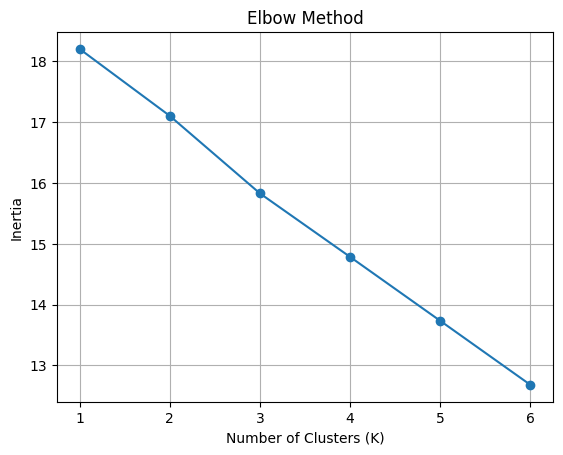

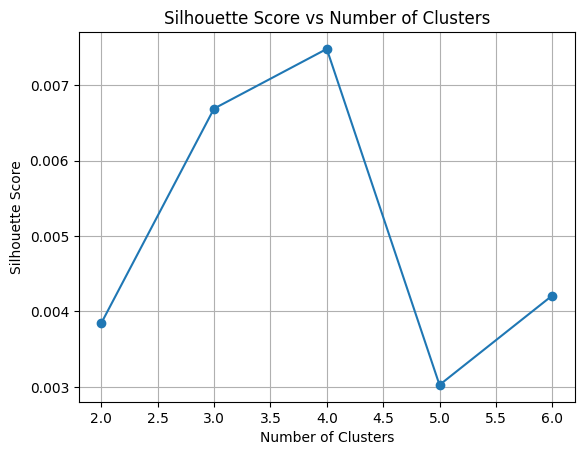


Clustered Data:

                                          review  \
0    This product is amazing and works perfectly   
1               Very bad quality, waste of money   
2        Excellent performance and fast delivery   
3       Terrible product, not recommended at all   
4          Good value for money and nice quality   
5       Worst experience ever, very disappointed   
6             Highly satisfied with the purchase   
7                 Poor packaging and bad quality   
8          Amazing battery life and great design   
9     Not worth the price, very poor performance   
10           Fast delivery and excellent service   
11        Product stopped working after one week   
12  Really happy with the quality and durability   
13        Bad customer support and late delivery   
14      Superb product, exceeded my expectations   
15       Cheap quality materials used in product   
16              Very comfortable and easy to use   
17               Waste of money, do not buy th

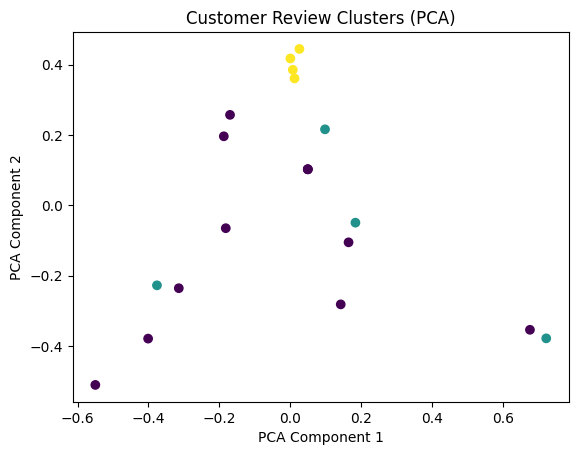

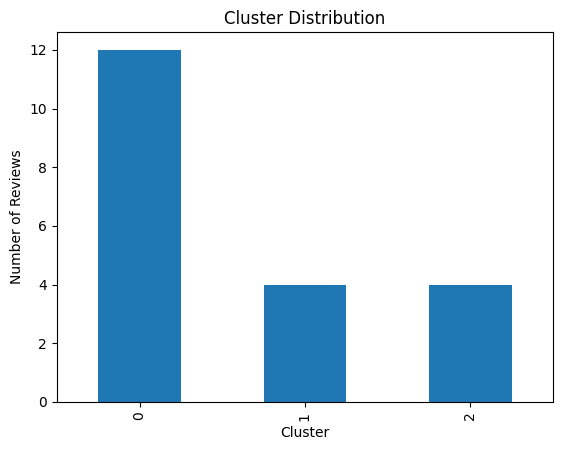


Top words in Cluster 0:
quality
bad
waste
packaging
poor
money
delivery
product
buy
damaged

Top words in Cluster 1:
value
performance
great
outstanding
nice
fast
excellent
delivery
life
design

Top words in Cluster 2:
product
terrible
recommended
works
perfectly
expectations
superb
exceeded
amazing
week


In [8]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# 1. DATASET
reviews = [
    "This product is amazing and works perfectly",
    "Very bad quality, waste of money",
    "Excellent performance and fast delivery",
    "Terrible product, not recommended at all",
    "Good value for money and nice quality",
    "Worst experience ever, very disappointed",
    "Highly satisfied with the purchase",
    "Poor packaging and bad quality",
    "Amazing battery life and great design",
    "Not worth the price, very poor performance",
    "Fast delivery and excellent service",
    "Product stopped working after one week",
    "Really happy with the quality and durability",
    "Bad customer support and late delivery",
    "Superb product, exceeded my expectations",
    "Cheap quality materials used in product",
    "Very comfortable and easy to use",
    "Waste of money, do not buy this",
    "Packaging was damaged but product is good",
    "Outstanding performance and great value"
]
df = pd.DataFrame(reviews, columns=["review"])

# 2. PREPROCESSING
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['cleaned'] = df['review'].apply(clean_text)

# 3. TF-IDF FEATURE EXTRACTION
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['cleaned'])

# 4. ELBOW METHOD
inertia = []
K_range = range(1, 7)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid()
plt.show()

# 5. SILHOUETTE SCORE GRAPH
silhouette_scores = []

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure()
plt.plot(range(2, 7), silhouette_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.grid()
plt.show()

# 6. FINAL K-MEANS MODEL
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

print("\nClustered Data:\n")
print(df)

# 7. PCA VISUALIZATION
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'])
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Review Clusters (PCA)")
plt.show()

# 8. CLUSTER DISTRIBUTION
cluster_counts = df['cluster'].value_counts().sort_index()

plt.figure()
cluster_counts.plot(kind='bar')
plt.xlabel("Cluster")
plt.ylabel("Number of Reviews")
plt.title("Cluster Distribution")
plt.show()

# 9. TOP WORDS PER CLUSTER
terms = vectorizer.get_feature_names_out()

for i in range(k):
    print(f"\nTop words in Cluster {i}:")
    center = kmeans.cluster_centers_[i]
    top_indices = center.argsort()[-10:][::-1]
    
    for idx in top_indices:
        print(terms[idx])